# 03. The Bayesian structural time-series model, fitted by ADVI

This is the project's Bayesian forecaster, the BSTS: a seasonal regression on
the shared design with a stationary AR(2) error and a heteroskedastic
observation scale. I fit it here by full-rank ADVI. Notebook 04 certifies the
same posterior with NUTS and checks the variational approximation against it.

**Why an AR(2) error.** The regression captures the seasonal and weather
shape; the error carries what it leaves behind. An AR(1) error carries only
the residual level forward and reverts at a fixed rate, so its slope at the
forecast origin is pinned by that one number. An AR(2) error carries the last
two residuals, so the forecast starts from a level and a slope, the curvature
the residual diagnostics ask for (a large negative lag-2 partial
autocorrelation). That is where the model's short-lead sharpness comes from.
The classical ARIMA, left to choose its own order on validation, settles on
AR(1) (notebook 02); here the second lag earns its place through short-lead
sharpness, not by mimicking the baseline.

## The model

On demand standardised over the fitting window, the regression residual
follows a stationary AR(2):

$$
e_t = y_t - x_t^\top \beta, \qquad
e_t - \rho_1 e_{t-1} - \rho_2 e_{t-2} \sim \mathcal{N}(0, \sigma_t^2), \qquad
\log \sigma_t = \gamma_0 + z_t^\top \gamma.
$$

Every symbol:

- $y_t$: standardised demand at half hour $t$.
- $x_t$: the mean-design row (seasonal harmonics, weather, degree days, demand
  lags, holiday, interactions); $\beta$ its regression coefficients.
- $e_t$: the regression residual, the error the AR(2) models.
- $\rho_1, \rho_2$: the AR(2) coefficients.
- $\sigma_t$: the observation scale at $t$; $z_t$ the variance-design row (a
  small daily basis and degree days), with intercept $\gamma_0$ and
  coefficients $\gamma$.

The coefficients are sampled through their partial autocorrelations, which
keeps every draw stationary: $\phi_1$ (the lag-1 PACF, a $\mathrm{Beta}$ prior
on $(0,1)$) and $\phi_2$ (the lag-2 PACF, uniform on $(-1,1)$), with
$\rho_1 = \phi_1(1-\phi_2)$ and $\rho_2 = \phi_2$. The first two residuals are
anchored at their stationary distribution. Writing the likelihood on the
innovations leaves nothing sequential: the residuals are one matrix product
and the innovations a shifted difference, so there is no scan and the fit
takes seconds.

```mermaid
flowchart TD
  x[x_t mean design: harmonics, weather, degree days, lags, holiday] --> mu[mu_t regression mean = x_t' beta]
  beta[beta regression coefficients] --> mu
  z[z_t variance design: daily basis, degree days] --> sigma[sigma_t observation scale]
  gamma0[gamma0 log-scale intercept] --> sigma
  gamma[gamma log-scale coefficients] --> sigma
  phi1[phi1 lag-1 PACF] --> rho[rho1, rho2 AR2 coefficients]
  phi2[phi2 lag-2 PACF] --> rho
  rho --> e[e_t AR2 error]
  sigma --> e
  mu --> y[y_t demand]
  e --> y
```

## ADVI, with the ELBO watched in parts

ADVI maximises the evidence lower bound, the ELBO, over a Gaussian variational
approximation $q$, and that bound splits exactly into two readable pieces:

$$ \mathrm{ELBO} = \underbrace{\mathbb{E}_q[\log p(y, \theta)]}_{\text{energy}}
   + \underbrace{\mathbb{H}[q]}_{\text{entropy}}, $$

the energy (how well $q$ sits under the model) and the entropy (how spread out
it stays). Watching them separately makes under-dispersion visible during
training, as the entropy collapses while the energy keeps climbing. I use a
full-rank approximation (`AutoMultivariateNormal`), whose covariance can carry
the correlations between the persistence, the variance head and the regression.

In [1]:
import os

os.environ.setdefault("JAX_PLATFORMS", "cpu")  # notebook JAX work is light; leave the GPU to fits

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from nemforecastdemand.config import load_config
from nemforecastdemand.data.loaders import load_panel, load_splits
from nemforecastdemand.evaluation.metrics import crps_gaussian, crps_samples
from nemforecastdemand.models import bsts
from nemforecastdemand.models.predict import variance_decomposition_innovations
from nemforecastdemand.plotting import MODEL_COLOURS, fan_chart, palette, save_figure, setup_style
from nemforecastdemand.splits import rolling_origins
from nemforecastdemand.utils import load_artifact

setup_style()
cfg = load_config()
panel = load_panel(cfg.paths.processed)
splits = load_splits(cfg.paths.processed)
max_lag = max(cfg.features.demand_lags)

fr_arrays, fr_meta = load_artifact(cfg.paths.artifacts / "bsts_innovations_vi_fullrank")
arima_arrays, arima_meta = load_artifact(cfg.paths.artifacts / "arima")

test_origins = rolling_origins(splits["test"].index, panel.index, cfg.origins, cfg.horizon, max_lag)
fit_index = splits["train"].index[max_lag:]
inputs = bsts.prepare_inputs(panel, cfg, fit_index)
y_test = fr_arrays["y_test"]
hours = (np.arange(cfg.horizon) + 1) / 2
AR_SITES = ("phi1", "phi2", "beta", "gamma0", "gamma")
BLUE, ACCENT = palette("demand"), palette("accent")  # BLUE is the canonical BSTS colour


def per_horizon_crps(paths: np.ndarray) -> np.ndarray:
    """Mean CRPS at each lead time from sampled paths, (H,)."""
    return np.stack([crps_samples(y_test[:, h], paths[:, :, h]).mean() for h in range(cfg.horizon)])

/home/s95717/miniforge3/envs/nem-demand-forecast/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


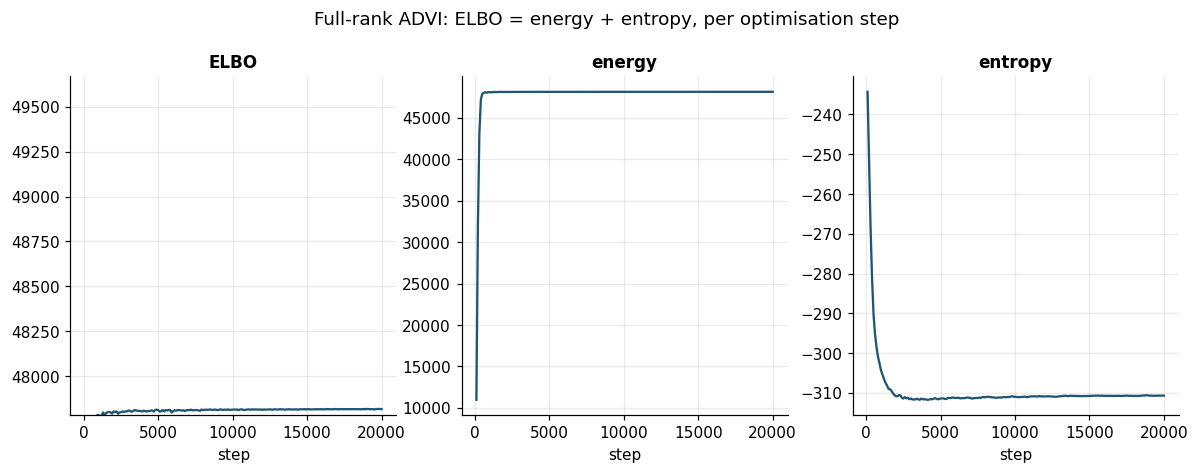

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].plot(fr_arrays["elbo_steps"], fr_arrays["elbo"], color=BLUE)
axes[1].plot(fr_arrays["elbo_steps"], fr_arrays["energy"], color=BLUE)
axes[2].plot(fr_arrays["elbo_steps"], fr_arrays["entropy"], color=BLUE)
for ax, title in zip(axes, ("ELBO", "energy", "entropy"), strict=True):
    ax.set_title(title)
    ax.set_xlabel("step")
axes[0].set_ylim(bottom=np.quantile(fr_arrays["elbo"], 0.05))
fig.suptitle("Full-rank ADVI: ELBO = energy + entropy, per optimisation step", y=1.03)
save_figure(fig, "elbo_decomposition", cfg.paths.figures)
plt.show()

*Takeaway: the ELBO climbs and plateaus cleanly, with the entropy settling rather than collapsing, so the approximation is not silently under-dispersing.*

In [3]:
def plateau_drift(elbo: np.ndarray, window: int = 20) -> str:
    """Relative ELBO drift between the last two checkpoint windows."""
    recent = elbo[-window:].mean()
    previous = elbo[-2 * window : -window].mean()
    return f"{abs(recent - previous) / abs(previous):.2%}"


pd.DataFrame(
    {
        "BSTS-ADVI-FR": {
            "final ELBO": fr_meta["final_elbo"],
            "plateau drift, last 2k steps": plateau_drift(fr_arrays["elbo"]),
            "fit seconds": fr_meta["timings_seconds"]["fit_seconds"],
            "device": fr_meta["device"],
        }
    }
).T

,final ELBO,"plateau drift, last 2k steps",fit seconds,device
BSTS-ADVI-FR,47815.0625,0.00%,5.860699,gpu


*Takeaway: the fit converges (drift under a fraction of a percent) in seconds, because the innovations form has no sequential scan in the gradient.*

## The posterior is correlated, so the approximation is full-rank

Persistence and the variance head trade off against the regression: a larger
$\rho$ carries more of each residual, which leaves less for $\beta$ to explain.
That makes the posterior genuinely correlated, which is why the approximation
is full-rank: its dense covariance captures these correlations, where a
diagonal one would miss them. Notebook 04 certifies the full-rank approximation
against the NUTS reference and measures how far it sits from the truth.

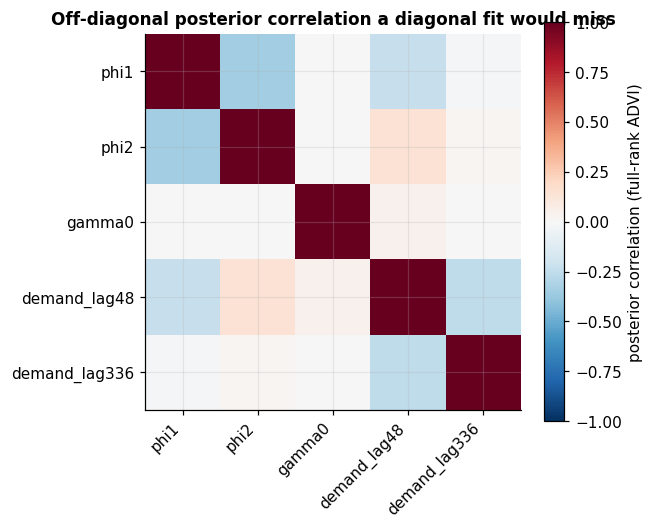

In [4]:
labels = ["phi1", "phi2", "gamma0"]
draws_fr = np.column_stack([fr_arrays[f"draw_{name}"] for name in labels])
beta_fr = fr_arrays["draw_beta"]
lag_cols = [i for i, c in enumerate(inputs.columns) if "lag" in c]
draws_fr = np.column_stack([draws_fr, beta_fr[:, lag_cols]])
labels = labels + [inputs.columns[i] for i in lag_cols]
corr = np.corrcoef(draws_fr.T)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(labels)), labels, rotation=45, ha="right")
ax.set_yticks(range(len(labels)), labels)
fig.colorbar(im, label="posterior correlation (full-rank ADVI)")
ax.set_title("Off-diagonal posterior correlation a diagonal fit would miss")
fig.tight_layout()
plt.show()

*Takeaway: the persistence, variance-head and lag coefficients carry clear off-diagonal correlation, which only a full-rank approximation can represent.*

## Persistence and the learned variance profile

The lag-1 coefficient lands deep in the persistent regime and the lag-2
coefficient comes out firmly negative, the slope-carrying term the residual
diagnostics asked for. The variance head reproduces the daily risk profile:
narrow bands through the small hours, wide bands across the afternoon and
evening ramps. The choice of a heteroskedastic scale is justified straight
from the data in the EDA (notebook 01).

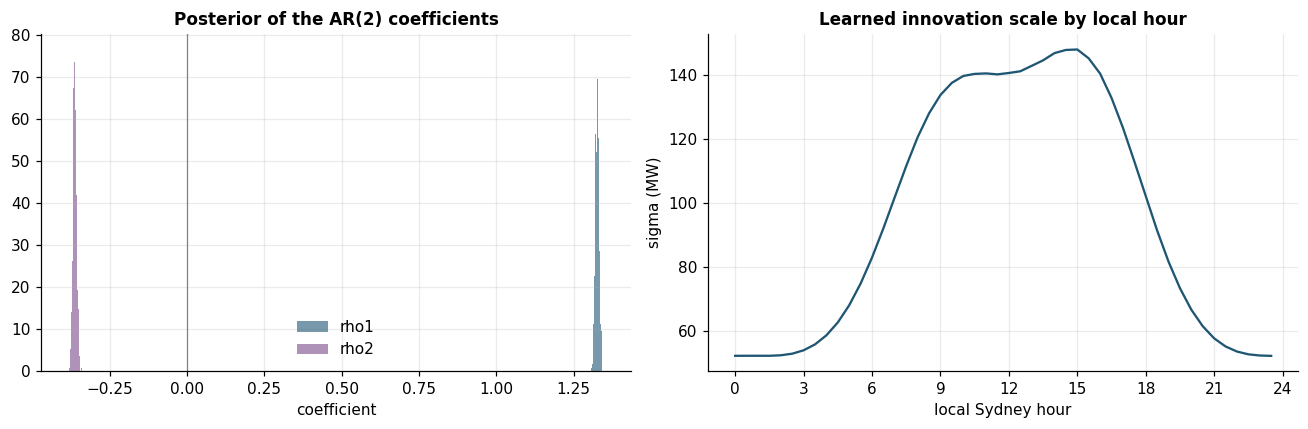

In [5]:
def ar_coeffs(arrays: dict) -> dict[str, np.ndarray]:
    """AR(2) coefficients and the variance intercept from a fit's draws."""
    rho1 = arrays["draw_phi1"] * (1.0 - arrays["draw_phi2"])
    return {"rho1": rho1, "rho2": arrays["draw_phi2"], "gamma0": arrays["draw_gamma0"]}


local_hour = fit_index.tz_convert("Australia/Sydney")
hour_frac = local_hour.hour + local_hour.minute / 60

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fr_coeffs = ar_coeffs(fr_arrays)
for name, colour in (("rho1", BLUE), ("rho2", ACCENT)):
    axes[0].hist(fr_coeffs[name], bins=40, density=True, alpha=0.6, color=colour, label=name)
axes[0].axvline(0.0, color="grey", lw=0.8)
axes[0].set_title("Posterior of the AR(2) coefficients")
axes[0].set_xlabel("coefficient")
axes[0].legend()

gamma0 = fr_arrays["draw_gamma0"][:, None]
gamma = fr_arrays["draw_gamma"]
log_sigma = gamma0 + gamma @ inputs.x_var.T
sigma_mw = np.exp(log_sigma) * inputs.y_scale
profile = pd.DataFrame({"hour": hour_frac, "sigma": sigma_mw.mean(axis=0)}).groupby("hour").mean()
axes[1].plot(profile.index, profile["sigma"], color=BLUE)
axes[1].set_title("Learned innovation scale by local hour")
axes[1].set_xlabel("local Sydney hour")
axes[1].set_ylabel("sigma (MW)")
axes[1].set_xticks(np.arange(0, 25, 3))
fig.tight_layout()
save_figure(fig, "bsts_coeffs_and_variance", cfg.paths.figures)
plt.show()

*Takeaway: a persistent lag-1 and a firmly negative lag-2 give the error its origin slope, and the learned scale is narrow overnight and wide across the evening ramp.*

## Forecasts

Each forecast carries the two observed origin residuals forward under that
draw's AR(2) coefficients, a level and a slope rather than just a decaying
level, with the innovations accumulating at the covariate-driven scale. That
gives one coherent 48-step path per draw. The CRPS uses the energy-form sample
estimator, unit-tested against the analytic Gaussian form.

In [6]:
crps_rows = {
    "BSTS-ADVI-FR": float(
        np.mean(
            [
                crps_samples(y_test[i], fr_arrays["forecast_paths"][:, i, :]).mean()
                for i in range(y_test.shape[0])
            ]
        )
    ),
    "ARIMA": float(
        crps_gaussian(
            arima_arrays["y_test"], arima_arrays["forecast_mean"], arima_arrays["forecast_sd"]
        ).mean()
    ),
}
pd.Series(crps_rows, name="test CRPS (MW), archived forecast weather").to_frame().round(1)

,"test CRPS (MW), archived forecast weather"
BSTS-ADVI-FR,272.4
ARIMA,258.0


*Takeaway: on overall CRPS the BSTS and ARIMA are close; the difference is where each wins across the horizon.*

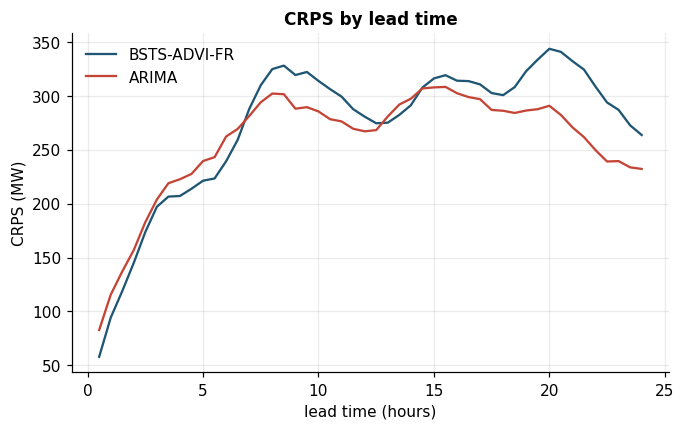

In [7]:
ar_curve = per_horizon_crps(fr_arrays["forecast_paths"])
arima_curve = np.stack(
    [
        crps_gaussian(
            y_test[:, h], arima_arrays["forecast_mean"][:, h], arima_arrays["forecast_sd"][:, h]
        ).mean()
        for h in range(cfg.horizon)
    ]
)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(hours, ar_curve, color=BLUE, label="BSTS-ADVI-FR")
ax.plot(hours, arima_curve, color=MODEL_COLOURS["ARIMA"], label="ARIMA")
ax.set_xlabel("lead time (hours)")
ax.set_ylabel("CRPS (MW)")
ax.set_title("CRPS by lead time")
ax.legend()
save_figure(fig, "bsts_horizon_crps", cfg.paths.figures)
plt.show()

*Takeaway: the BSTS is much sharper in the first hours, where the AR(2) carry reads the origin residuals; ARIMA catches up at long lead.*

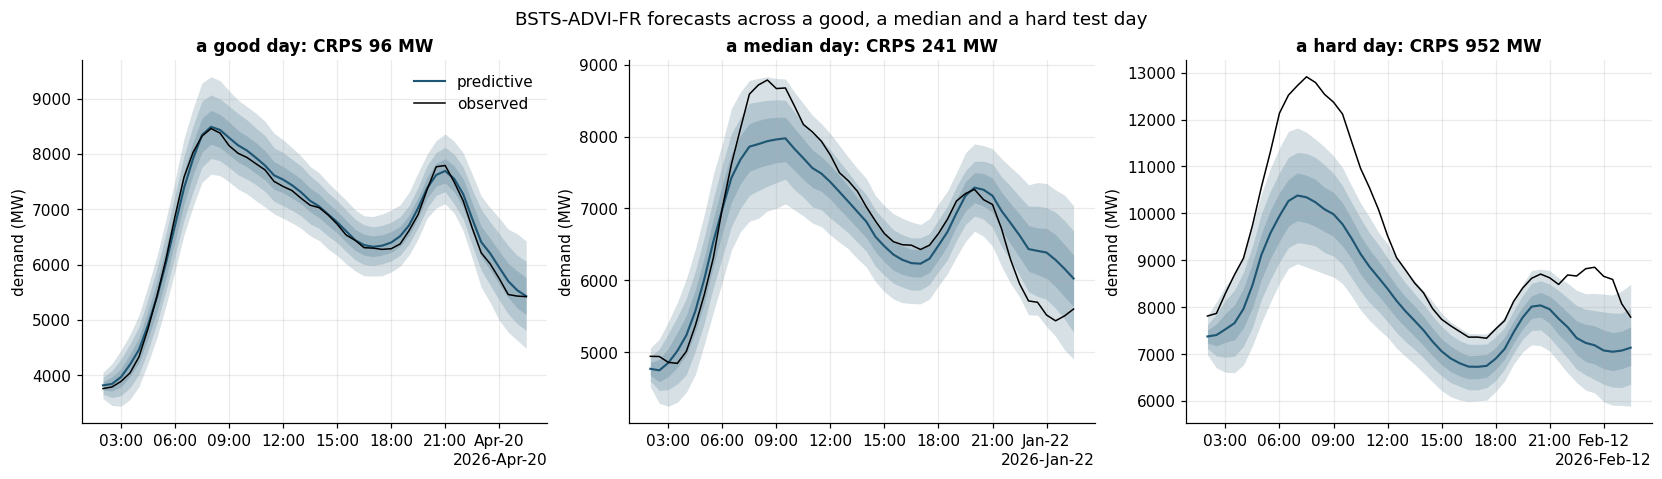

In [8]:
fr_paths = fr_arrays["forecast_paths"]
daily_crps = np.stack(
    [crps_samples(y_test[i], fr_paths[:, i, :]).mean() for i in range(y_test.shape[0])]
)
order = np.argsort(daily_crps)
picks = [
    ("a good day", int(order[0])),
    ("a median day", int(order[len(order) // 2])),
    ("a hard day", int(order[-1])),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)
for ax, (label, pos) in zip(axes, picks, strict=True):
    origin = test_origins[pos]
    index = pd.date_range(origin, periods=cfg.horizon, freq="30min")
    fan_chart(ax, index, samples=fr_paths[:, pos, :], colour=BLUE, label="predictive")
    ax.plot(
        index.tz_convert("Australia/Brisbane"), y_test[pos], color="black", lw=1.0, label="observed"
    )
    ax.set_title(f"{label}: CRPS {daily_crps[pos]:.0f} MW")
    ax.set_ylabel("demand (MW)")
axes[0].legend()
fig.suptitle("BSTS-ADVI-FR forecasts across a good, a median and a hard test day", y=1.05)
save_figure(fig, "bsts_vi_fan_charts", cfg.paths.figures)
plt.show()

*Takeaway: the bands track the observed across regimes; even the hard day is an extreme peak the predictive widens to acknowledge rather than misses outright.*

## The predictive variance, decomposed

Conditional on a draw the h-step predictive is Gaussian, so the law of total
variance splits the predictive into two exact parts. The origin residuals are
observed, so there is no state term:

- **parameter** (epistemic): variance across draws of the conditional mean,
  the uncertainty more data would shrink;
- **alea** (aleatoric): the accumulated AR-carried noise. *Alea* is the chance
  term (Latin for a die), the irreducible part no amount of data removes.

The epistemic share doubles as an inference diagnostic, because an
under-dispersed approximation has to understate it. That is the check notebook
04 runs against NUTS.

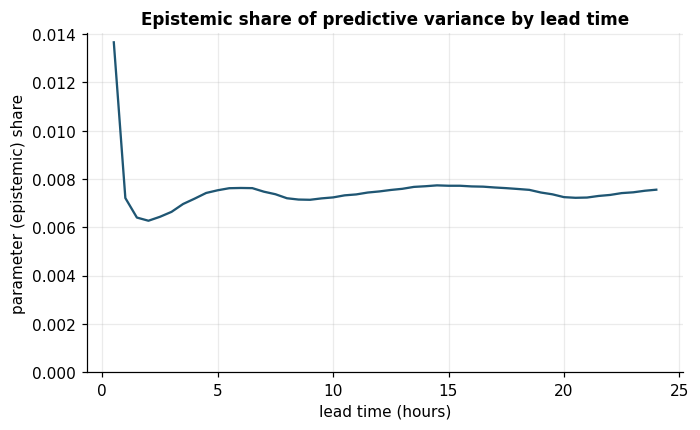

In [9]:
ar_decomp = variance_decomposition_innovations(
    {site: fr_arrays[f"draw_{site}"] for site in AR_SITES}, inputs, panel, cfg, test_origins
)
total = ar_decomp["parameter"] + ar_decomp["innovation"]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(hours, (ar_decomp["parameter"] / total).mean(axis=0), color=BLUE)
ax.set_xlabel("lead time (hours)")
ax.set_ylabel("parameter (epistemic) share")
ax.set_ylim(0, None)
ax.set_title("Epistemic share of predictive variance by lead time")
save_figure(fig, "innovations_variance_decomposition", cfg.paths.figures)
plt.show()

*Takeaway: the epistemic share is small at every lead, so with two years of training the parameters are well pinned and almost all predictive uncertainty is irreducible.*

In [10]:
pd.DataFrame(
    {
        "BSTS-ADVI-FR": {
            "parameter share": float((ar_decomp["parameter"] / total).mean()),
            "alea share": float((ar_decomp["innovation"] / total).mean()),
            "mean predictive sd (MW)": float(np.sqrt(total.mean())),
        }
    }
).T.round(3)

,parameter share,alea share,mean predictive sd (MW)
BSTS-ADVI-FR,0.007,0.993,452.074


*Takeaway: the alea (aleatoric) term dominates the predictive variance, confirming the epistemic share read off the curve above.*

## Summary

- The BSTS is a seasonal regression with a stationary AR(2) error and a
  heteroskedastic scale. The lag-2 term gives the error a slope at the origin
  that an AR(1) error cannot carry, which is where the short-lead sharpness
  comes from.
- Full-rank ADVI fits it in seconds and converges cleanly, with no sign of the
  entropy collapse that signals under-dispersion.
- The posterior is correlated, so a full-rank approximation is the right
  choice; notebook 04 measures how far it sits from the NUTS reference.
- The predictive variance splits into a small epistemic part and a dominant
  irreducible innovation part, and that split is the inference diagnostic
  notebook 04 audits.